In [2]:
import pandas as pd
from sqlalchemy import create_engine

In [3]:
# Read the Files & Understand what kind of data is available in all the files
# 1. Extract
accounts = pd.read_csv('Dim_Accounts.csv')
products = pd.read_csv('Dim_Products.csv')
leads = pd.read_csv('Fact_Leads.csv')
sales = pd.read_csv('Fact_Sales.csv')

In [4]:
## check data & headers of all the tables
accounts.head()

,Account_ID,Company_Name,Market,Country,Industry,Account_Tier
0,ACC01,Reliance Industries,Domestic,India,Petrochemical,Enterprise
1,ACC02,Pfizer Inc.,International,USA,Pharma,Enterprise
2,ACC03,Tata Power,Domestic,India,Energy,Mid-Market
3,ACC04,Bayer AG,International,Germany,Agriculture,Enterprise
4,ACC05,Sun Pharma,Domestic,India,Pharma,Enterprise


In [5]:
products.head()

,Product_ID,Product_Name,Category,Unit_Cost,Standard_Price,Profit_Margin_Target,Selling_Price
0,P001,SuperExC18H,Cation,200,300,55%,465.0
1,P002,SuperExC18Na,Cation,250,350,60%,560.0
2,P003,EDMAXG,Mixed Bed,250,350,75%,612.5
3,P004,EDMAXM,Mixed Bed,270,370,55%,573.5
4,P005,SuperExA14Cl,Anion,500,600,45%,870.0


In [6]:
leads.head()

,Lead_ID,Account_ID,Product_ID,Lead_Source,Created_Date,Status,Lead_Score
0,L001,ACC47,P001,LinkedIn,10-01-2024,Converted,85
1,L002,ACC48,P003,Indiamart,12-01-2024,Converted,90
2,L003,ACC50,P005,Website,15-01-2024,Converted,40
3,L004,ACC12,P002,Referral,20-01-2024,Converted,75
4,L005,ACC26,P008,Outbound,01-02-2024,Converted,55


In [7]:
sales.head()

,Transaction_ID,Lead_ID,Account_ID,Product_ID,Close_Date,Qty,Unit_Price,Total_Amount
0,T001,L001,ACC47,P001,28-01-2024,22500,465.0,10462500.0
1,T002,L002,ACC48,P003,06-02-2024,6500,612.5,3981250.0
2,T003,L004,ACC12,P002,04-02-2024,15500,560.0,8680000.0
3,T004,L006,ACC07,P010,21-02-2024,11500,526.5,6054750.0
4,T005,L007,ACC36,P007,18-02-2024,14000,747.0,10458000.0


In [9]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            10 non-null     object 
 1   Product_Name          10 non-null     object 
 2   Category              10 non-null     object 
 3   Unit_Cost             10 non-null     int64  
 4   Standard_Price        10 non-null     int64  
 5   Profit_Margin_Target  10 non-null     object 
 6   Selling_Price         10 non-null     float64
dtypes: float64(1), int64(2), object(4)
memory usage: 692.0+ bytes


In [10]:
leads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Lead_ID       200 non-null    object
 1   Account_ID    200 non-null    object
 2   Product_ID    200 non-null    object
 3   Lead_Source   200 non-null    object
 4   Created_Date  200 non-null    object
 5   Status        200 non-null    object
 6   Lead_Score    200 non-null    int64 
dtypes: int64(1), object(6)
memory usage: 11.1+ KB


In [11]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Transaction_ID  1500 non-null   object 
 1   Lead_ID         1500 non-null   object 
 2   Account_ID      1500 non-null   object 
 3   Product_ID      1500 non-null   object 
 4   Close_Date      1500 non-null   object 
 5   Qty             1500 non-null   int64  
 6   Unit_Price      1500 non-null   float64
 7   Total_Amount    1500 non-null   float64
dtypes: float64(2), int64(1), object(5)
memory usage: 93.9+ KB


In [12]:
leads.describe(include='all')

,Lead_ID,Account_ID,Product_ID,Lead_Source,Created_Date,Status,Lead_Score
count,200,200,200,200,200,200,200.000000
unique,200,50,10,5,158,1,NaN
top,L001,ACC47,P001,Website,15-05-2024,Converted,NaN
freq,1,9,30,50,4,200,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,57.170000
std,NaN,NaN,NaN,NaN,NaN,NaN,27.596174
min,NaN,NaN,NaN,NaN,NaN,NaN,10.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,33.750000
50%,NaN,NaN,NaN,NaN,NaN,NaN,58.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,83.000000


In [13]:
sales.describe(include='all')

,Transaction_ID,Lead_ID,Account_ID,Product_ID,Close_Date,Qty,Unit_Price,Total_Amount
count,1500,1500,1500,1500,1500,1500.000000,1500.000000,1.500000e+03
unique,1500,30,24,10,361,NaN,NaN,NaN
top,T1500,L021,ACC29,P001,24-04-2024,NaN,NaN,NaN
freq,1,55,106,240,11,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,13500.333333,647.693000,8.727587e+06
std,NaN,NaN,NaN,NaN,NaN,6539.929689,145.838285,4.760040e+06
min,NaN,NaN,NaN,NaN,NaN,2500.000000,465.000000,1.162500e+06
25%,NaN,NaN,NaN,NaN,NaN,7875.000000,526.500000,4.785000e+06
50%,NaN,NaN,NaN,NaN,NaN,13500.000000,612.500000,8.268750e+06
75%,NaN,NaN,NaN,NaN,NaN,19000.000000,850.000000,1.195650e+07


In [14]:
accounts.describe(include='all')

,Account_ID,Company_Name,Market,Country,Industry,Account_Tier
count,50,50,50,50,50,50
unique,50,50,2,7,10,2
top,ACC01,Reliance Industries,Domestic,India,Pharma,Enterprise
freq,1,1,25,25,15,39


In [15]:
products.describe(include='all')

,Product_ID,Product_Name,Category,Unit_Cost,Standard_Price,Profit_Margin_Target,Selling_Price
count,10,10,10,10.000000,10.000000,10,10.000000
unique,10,10,4,NaN,NaN,9,NaN
top,P001,SuperExC18H,Mixed Bed,NaN,NaN,55%,NaN
freq,1,1,4,NaN,NaN,2,NaN
mean,NaN,NaN,NaN,314.000000,414.000000,NaN,632.850000
std,NaN,NaN,NaN,87.838235,87.838235,NaN,143.154743
min,NaN,NaN,NaN,200.000000,300.000000,NaN,465.000000
25%,NaN,NaN,NaN,255.000000,355.000000,NaN,534.875000
50%,NaN,NaN,NaN,285.000000,385.000000,NaN,593.000000
75%,NaN,NaN,NaN,350.000000,450.000000,NaN,717.750000


In [16]:
products.columns

Index(['Product_ID', 'Product_Name', 'Category', 'Unit_Cost', 'Standard_Price',
       'Profit_Margin_Target', 'Selling_Price'],
      dtype='object')

In [17]:
sales.columns

Index(['Transaction_ID', 'Lead_ID', 'Account_ID', 'Product_ID', 'Close_Date',
       'Qty', 'Unit_Price', 'Total_Amount'],
      dtype='object')

In [18]:
accounts.columns

Index(['Account_ID', 'Company_Name', 'Market', 'Country', 'Industry',
       'Account_Tier'],
      dtype='object')

In [19]:
leads.columns

Index(['Lead_ID', 'Account_ID', 'Product_ID', 'Lead_Source', 'Created_Date',
       'Status', 'Lead_Score'],
      dtype='object')

In [20]:
#Merge all 4 tables

# 1. Join Tables to create a single source

# Here sales table is important, hence merge Leads table to Sales table with left join
df_master = sales.merge(leads[['Lead_ID', 'Lead_Source', 'Created_Date', 'Status', 'Lead_Score']], on='Lead_ID', how='left')

# Whatever the result is will be stored in df_master, add Accounts table to that result table
df_master = df_master.merge(accounts, on='Account_ID', how='left')

# Again add Products table to that result table
df_master = df_master.merge(products[['Product_ID', 'Product_Name', 'Category', 'Unit_Cost']], on='Product_ID', how='left')


In [21]:
df_master

,Transaction_ID,Lead_ID,Account_ID,Product_ID,Close_Date,Qty,Unit_Price,Total_Amount,Lead_Source,Created_Date,Status,Lead_Score,Company_Name,Market,Country,Industry,Account_Tier,Product_Name,Category,Unit_Cost
0,T001,L001,ACC47,P001,28-01-2024,22500,465.0,10462500.0,LinkedIn,10-01-2024,Converted,85,Britannia Industries,Domestic,USA,Infrastructure,Enterprise,SuperExC18H,Cation,200
1,T002,L002,ACC48,P003,06-02-2024,6500,612.5,3981250.0,Indiamart,12-01-2024,Converted,90,Diageo India,International,India,Pharma,Mid-Market,EDMAXG,Mixed Bed,250
2,T003,L004,ACC12,P002,04-02-2024,15500,560.0,8680000.0,Referral,20-01-2024,Converted,75,Dow Chemical,International,USA,Chemicals,Enterprise,SuperExC18Na,Cation,250
3,T004,L006,ACC07,P010,21-02-2024,11500,526.5,6054750.0,Website,05-02-2024,Converted,88,Adani Group,Domestic,India,Infrastructure,Enterprise,SuperMENitrex,Media,290
4,T005,L007,ACC36,P007,18-02-2024,14000,747.0,10458000.0,Indiamart,10-02-2024,Converted,92,Lupin Limited,International,USA,Oil & Gas,Enterprise,SuperExMB50,Mixed Bed,350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,T1496,L046,ACC29,P008,03-04-2024,12000,850.0,10200000.0,Website,25-06-2024,Converted,68,ONGC,Domestic,India,Mining,Mid-Market,SuperExMB60,Mixed Bed,400
1496,T1497,L001,ACC20,P007,10-07-2024,21000,747.0,15687000.0,LinkedIn,10-01-2024,Converted,85,Sinopec Group,International,China,Oil & Gas,Enterprise,SuperExMB50,Mixed Bed,350
1497,T1498,L002,ACC03,P002,29-01-2024,16000,560.0,8960000.0,Indiamart,12-01-2024,Converted,90,Tata Power,Domestic,India,Energy,Mid-Market,SuperExC18Na,Cation,250
1498,T1499,L004,ACC37,P006,22-09-2024,9000,630.0,5670000.0,Referral,20-01-2024,Converted,75,Aurobindo Pharma,Domestic,India,Pharma,Mid-Market,SuperExA14OH,Anion,350


In [22]:
df_master.shape

(1500, 20)

In [23]:
df_master.dtypes

Transaction_ID     object
Lead_ID            object
Account_ID         object
Product_ID         object
Close_Date         object
Qty                 int64
Unit_Price        float64
Total_Amount      float64
Lead_Source        object
Created_Date       object
Status             object
Lead_Score          int64
Company_Name       object
Market             object
Country            object
Industry           object
Account_Tier       object
Product_Name       object
Category           object
Unit_Cost           int64
dtype: object

In [24]:
# data cleaning
# Step 1: Date Conversions with 'dayfirst' fix
df_master['Close_Date'] = pd.to_datetime(df_master['Close_Date'], dayfirst=True)
df_master['Created_Date'] = pd.to_datetime(df_master['Created_Date'], dayfirst=True)



In [25]:
# 2. Clean hidden spaces from all column names immediately
df_master.columns = df_master.columns.str.strip()

In [26]:
# 3. Convert 'Total_Amount' from Text to Number
# We use errors='coerce' to handle any weird characters like currency symbols
df_master['Total_Amount'] = pd.to_numeric(df_master['Total_Amount'], errors='coerce')

In [27]:
df_master

,Transaction_ID,Lead_ID,Account_ID,Product_ID,Close_Date,Qty,Unit_Price,Total_Amount,Lead_Source,Created_Date,Status,Lead_Score,Company_Name,Market,Country,Industry,Account_Tier,Product_Name,Category,Unit_Cost
0,T001,L001,ACC47,P001,2024-01-28,22500,465.0,10462500.0,LinkedIn,2024-01-10,Converted,85,Britannia Industries,Domestic,USA,Infrastructure,Enterprise,SuperExC18H,Cation,200
1,T002,L002,ACC48,P003,2024-02-06,6500,612.5,3981250.0,Indiamart,2024-01-12,Converted,90,Diageo India,International,India,Pharma,Mid-Market,EDMAXG,Mixed Bed,250
2,T003,L004,ACC12,P002,2024-02-04,15500,560.0,8680000.0,Referral,2024-01-20,Converted,75,Dow Chemical,International,USA,Chemicals,Enterprise,SuperExC18Na,Cation,250
3,T004,L006,ACC07,P010,2024-02-21,11500,526.5,6054750.0,Website,2024-02-05,Converted,88,Adani Group,Domestic,India,Infrastructure,Enterprise,SuperMENitrex,Media,290
4,T005,L007,ACC36,P007,2024-02-18,14000,747.0,10458000.0,Indiamart,2024-02-10,Converted,92,Lupin Limited,International,USA,Oil & Gas,Enterprise,SuperExMB50,Mixed Bed,350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,T1496,L046,ACC29,P008,2024-04-03,12000,850.0,10200000.0,Website,2024-06-25,Converted,68,ONGC,Domestic,India,Mining,Mid-Market,SuperExMB60,Mixed Bed,400
1496,T1497,L001,ACC20,P007,2024-07-10,21000,747.0,15687000.0,LinkedIn,2024-01-10,Converted,85,Sinopec Group,International,China,Oil & Gas,Enterprise,SuperExMB50,Mixed Bed,350
1497,T1498,L002,ACC03,P002,2024-01-29,16000,560.0,8960000.0,Indiamart,2024-01-12,Converted,90,Tata Power,Domestic,India,Energy,Mid-Market,SuperExC18Na,Cation,250
1498,T1499,L004,ACC37,P006,2024-09-22,9000,630.0,5670000.0,Referral,2024-01-20,Converted,75,Aurobindo Pharma,Domestic,India,Pharma,Mid-Market,SuperExA14OH,Anion,350


In [28]:

# 4. Ensure Price and Cost are also Decimals (Floats) for accuracy
df_master['Unit_Price'] = df_master['Unit_Price'].astype(float)
df_master['Unit_Cost'] = df_master['Unit_Cost'].astype(float)

# 5. Profitability Calculation
df_master['Total_Cost'] = df_master['Qty'] * df_master['Unit_Cost']
df_master['Gross_Profit'] = df_master['Total_Amount'] - df_master['Total_Cost']
df_master['Profit_Margin_%'] = (df_master['Gross_Profit'] / df_master['Total_Amount']) * 100

print("Everything is fixed! New Data Types:")
print(df_master[['Total_Amount', 'Total_Cost', 'Gross_Profit', 'Profit_Margin_%']].dtypes)
df_master[['Transaction_ID', 'Total_Amount', 'Gross_Profit', 'Profit_Margin_%']].head()

Everything is fixed! New Data Types:
Total_Amount       float64
Total_Cost         float64
Gross_Profit       float64
Profit_Margin_%    float64
dtype: object


,Transaction_ID,Total_Amount,Gross_Profit,Profit_Margin_%
0,T001,10462500.0,5962500.0,56.989247
1,T002,3981250.0,2356250.0,59.183673
2,T003,8680000.0,4805000.0,55.357143
3,T004,6054750.0,2719750.0,44.919278
4,T005,10458000.0,5558000.0,53.145917


In [29]:
df_master

,Transaction_ID,Lead_ID,Account_ID,Product_ID,Close_Date,Qty,Unit_Price,Total_Amount,Lead_Source,Created_Date,...,Market,Country,Industry,Account_Tier,Product_Name,Category,Unit_Cost,Total_Cost,Gross_Profit,Profit_Margin_%
0,T001,L001,ACC47,P001,2024-01-28,22500,465.0,10462500.0,LinkedIn,2024-01-10,...,Domestic,USA,Infrastructure,Enterprise,SuperExC18H,Cation,200.0,4500000.0,5962500.0,56.989247
1,T002,L002,ACC48,P003,2024-02-06,6500,612.5,3981250.0,Indiamart,2024-01-12,...,International,India,Pharma,Mid-Market,EDMAXG,Mixed Bed,250.0,1625000.0,2356250.0,59.183673
2,T003,L004,ACC12,P002,2024-02-04,15500,560.0,8680000.0,Referral,2024-01-20,...,International,USA,Chemicals,Enterprise,SuperExC18Na,Cation,250.0,3875000.0,4805000.0,55.357143
3,T004,L006,ACC07,P010,2024-02-21,11500,526.5,6054750.0,Website,2024-02-05,...,Domestic,India,Infrastructure,Enterprise,SuperMENitrex,Media,290.0,3335000.0,2719750.0,44.919278
4,T005,L007,ACC36,P007,2024-02-18,14000,747.0,10458000.0,Indiamart,2024-02-10,...,International,USA,Oil & Gas,Enterprise,SuperExMB50,Mixed Bed,350.0,4900000.0,5558000.0,53.145917
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,T1496,L046,ACC29,P008,2024-04-03,12000,850.0,10200000.0,Website,2024-06-25,...,Domestic,India,Mining,Mid-Market,SuperExMB60,Mixed Bed,400.0,4800000.0,5400000.0,52.941176
1496,T1497,L001,ACC20,P007,2024-07-10,21000,747.0,15687000.0,LinkedIn,2024-01-10,...,International,China,Oil & Gas,Enterprise,SuperExMB50,Mixed Bed,350.0,7350000.0,8337000.0,53.145917
1497,T1498,L002,ACC03,P002,2024-01-29,16000,560.0,8960000.0,Indiamart,2024-01-12,...,Domestic,India,Energy,Mid-Market,SuperExC18Na,Cation,250.0,4000000.0,4960000.0,55.357143
1498,T1499,L004,ACC37,P006,2024-09-22,9000,630.0,5670000.0,Referral,2024-01-20,...,Domestic,India,Pharma,Mid-Market,SuperExA14OH,Anion,350.0,3150000.0,2520000.0,44.444444


In [30]:
df_master.dtypes

Transaction_ID             object
Lead_ID                    object
Account_ID                 object
Product_ID                 object
Close_Date         datetime64[ns]
Qty                         int64
Unit_Price                float64
Total_Amount              float64
Lead_Source                object
Created_Date       datetime64[ns]
Status                     object
Lead_Score                  int64
Company_Name               object
Market                     object
Country                    object
Industry                   object
Account_Tier               object
Product_Name               object
Category                   object
Unit_Cost                 float64
Total_Cost                float64
Gross_Profit              float64
Profit_Margin_%           float64
dtype: object

In [31]:
df_master.columns

Index(['Transaction_ID', 'Lead_ID', 'Account_ID', 'Product_ID', 'Close_Date',
       'Qty', 'Unit_Price', 'Total_Amount', 'Lead_Source', 'Created_Date',
       'Status', 'Lead_Score', 'Company_Name', 'Market', 'Country', 'Industry',
       'Account_Tier', 'Product_Name', 'Category', 'Unit_Cost', 'Total_Cost',
       'Gross_Profit', 'Profit_Margin_%'],
      dtype='object')

In [32]:
# check for null values
df_master.isnull().sum()


Transaction_ID     0
Lead_ID            0
Account_ID         0
Product_ID         0
Close_Date         0
Qty                0
Unit_Price         0
Total_Amount       0
Lead_Source        0
Created_Date       0
Status             0
Lead_Score         0
Company_Name       0
Market             0
Country            0
Industry           0
Account_Tier       0
Product_Name       0
Category           0
Unit_Cost          0
Total_Cost         0
Gross_Profit       0
Profit_Margin_%    0
dtype: int64

In [33]:
#Save the master file in system
df_master.to_csv('df_master.csv', index=False)


In [34]:
### Exploratory Data Analysis using Python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [35]:
# check the Summary Statistics
df = pd.read_csv('df_master.csv')

In [36]:
#Summary Statistics
df.describe()

,Qty,Unit_Price,Total_Amount,Lead_Score,Unit_Cost,Total_Cost,Gross_Profit,Profit_Margin_%
count,1500.000000,1500.000000,1.500000e+03,1500.000000,1500.000000,1.500000e+03,1.500000e+03,1500.000000
mean,13500.333333,647.693000,8.727587e+06,71.148000,322.586667,4.350523e+06,4.377064e+06,50.670683
std,6539.929689,145.838285,4.760040e+06,24.857367,93.703590,2.544297e+06,2.350235e+06,5.840363
min,2500.000000,465.000000,1.162500e+06,14.000000,200.000000,5.000000e+05,5.350000e+05,42.528736
25%,7875.000000,526.500000,4.785000e+06,66.000000,250.000000,2.375000e+06,2.405000e+06,44.444444
50%,13500.000000,612.500000,8.268750e+06,81.000000,290.000000,4.000000e+06,4.123125e+06,52.941176
75%,19000.000000,850.000000,1.195650e+07,89.000000,400.000000,5.801250e+06,5.918250e+06,55.357143
max,25000.000000,870.000000,2.175000e+07,99.000000,500.000000,1.250000e+07,1.125000e+07,59.183673


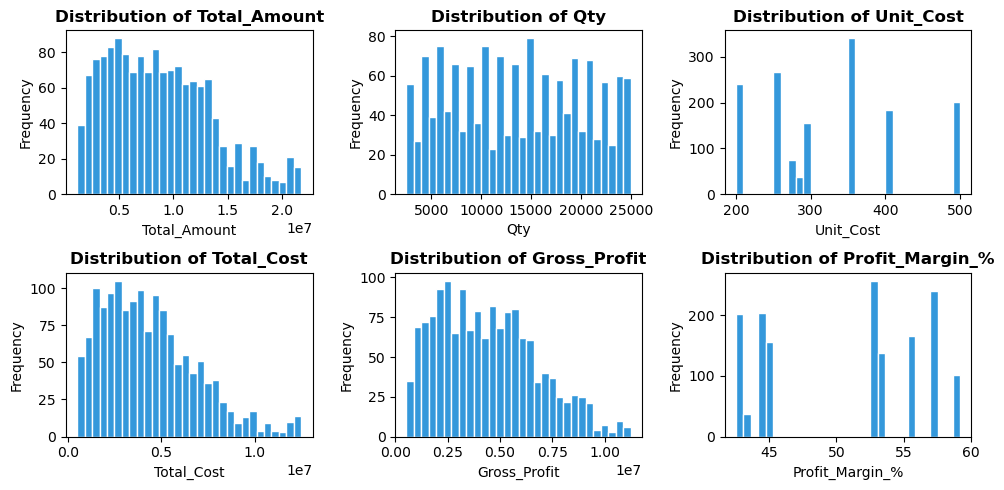

In [37]:
# Plot Histogram to check if there are outliers present in the data
# 1. Select key numeric columns
numeric_cols = ['Total_Amount', 'Qty','Unit_Cost','Total_Cost', 'Gross_Profit','Profit_Margin_%']

# 2. Set up the figure and subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 5))
axes = axes.flatten()

# 3. Plot histograms
for i, col in enumerate(numeric_cols):
    data = df_master[col].dropna()
    axes[i].hist(data, bins=30, color='#3498db', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()



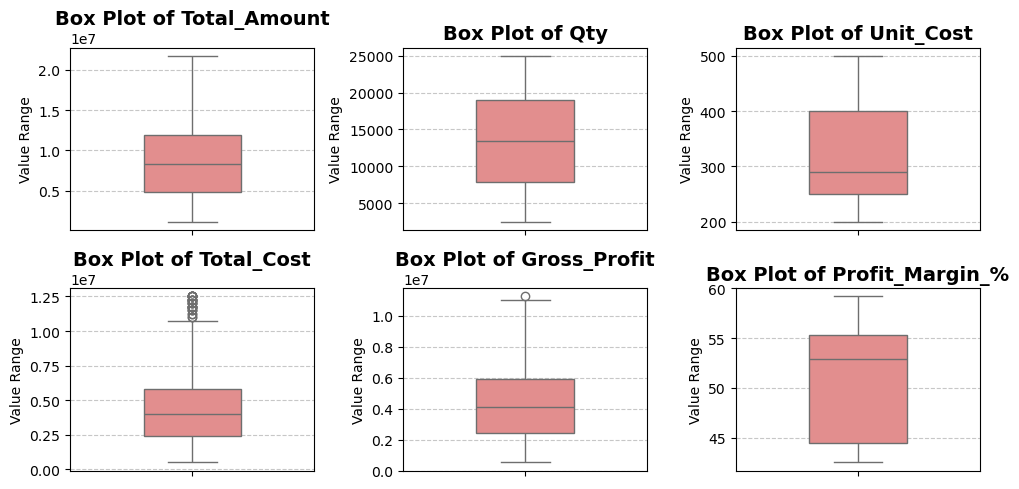

In [38]:
#Plot Box plots for same columns

# 1. Select the columns for the box plots
cols_to_plot = ['Total_Amount', 'Qty','Unit_Cost','Total_Cost', 'Gross_Profit','Profit_Margin_%']

# 2. Set up the figure (2 rows, 3 columns)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 5))
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

# 3. Loop through columns and create a box plot for each
for i, col in enumerate(cols_to_plot):
    if col in df_master.columns:
        sns.boxplot(y=df_master[col], ax=axes[i], color='lightcoral', width=0.4)
        
        # Add titles and labels for professional look
        axes[i].set_title(f'Box Plot of {col}', fontsize=14, fontweight='bold')
        axes[i].set_ylabel('Value Range')
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# 4. Adjust layout so titles don't overlap
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Industry Revenue Concentration (Pareto)')

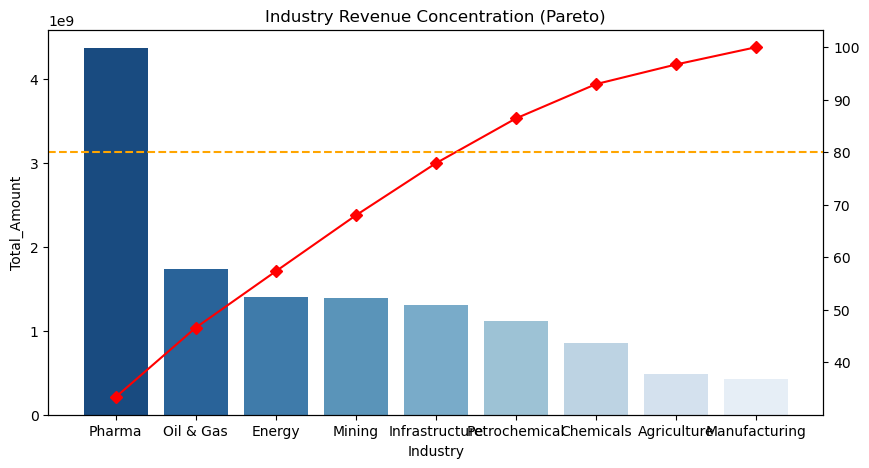

In [40]:

# 1. Pareto Analysis (Industry Revenue Concentration)
industry_rev = df_master.groupby('Industry')['Total_Amount'].sum().sort_values(ascending=False).reset_index()
industry_rev['cum_pct'] = 100 * industry_rev['Total_Amount'].cumsum() / industry_rev['Total_Amount'].sum()

fig, ax1 = plt.subplots(figsize=(10, 5))
sns.barplot(x='Industry', y='Total_Amount', data=industry_rev, ax=ax1, palette='Blues_r')
ax2 = ax1.twinx()
ax2.plot(industry_rev['Industry'], industry_rev['cum_pct'], color='red', marker='D', label='Cumulative %')
ax2.axhline(80, color='orange', linestyle='--') # The 80/20 Rule line
plt.title('Industry Revenue Concentration (Pareto)')


Text(0.5, 1.0, 'Is Lead Score Predicting Deal Value? (No Correlation)')

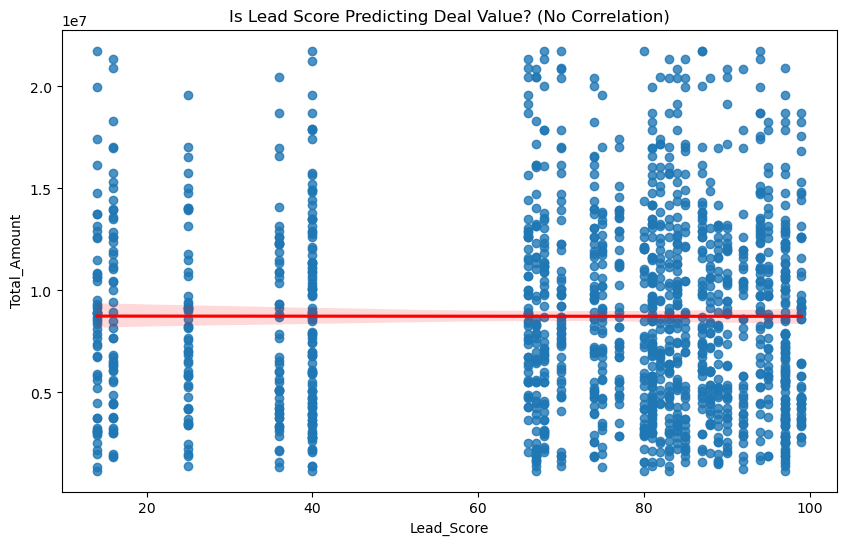

In [102]:
# 2. Lead Score Ineffectiveness (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.regplot(x='Lead_Score', y='Total_Amount', data=df_master, line_kws={'color':'red'})
plt.title('Is Lead Score Predicting Deal Value? (No Correlation)')

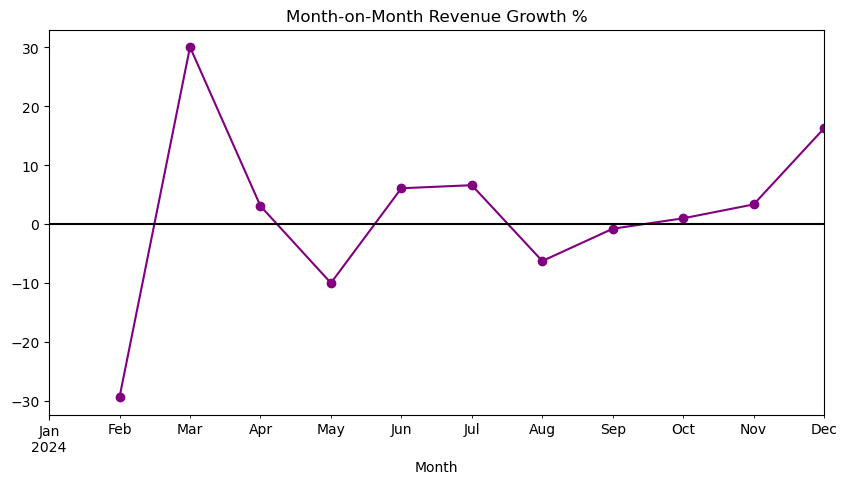

In [41]:
# 3. Monthly Growth Rate
df_master['Month'] = pd.to_datetime(df_master['Close_Date']).dt.to_period('M')
monthly = df_master.groupby('Month')['Total_Amount'].sum().pct_change() * 100
monthly.plot(kind='line', marker='o', color='purple', figsize=(10,5))
plt.axhline(0, color='black')
plt.title('Month-on-Month Revenue Growth %')

plt.show()

In [42]:


# Export to a final CSV
df_master.to_csv('Sales_Dashboard_Final.csv', index=False)

print("Final file 'Sales_Dashboard_Final.csv' is ready for Power BI import!")

Final file 'Sales_Dashboard_Final.csv' is ready for Power BI import!
